In [44]:
! pip install pandas numpy matplotlib openpyxl plotly nbformat seaborn scikit-learn xgboost

Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.3/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.5/101.7 MB 1.1 MB/s eta 0:01:31
   ---------------------------------------- 0.5/101.7 MB 1.1 MB/s eta 0:01:31
   ---------------------------------------- 1.0/101.7 MB 1.2 MB/s eta 0:01:24
    --------------------------------------- 1.3/101.7 MB 1.2 MB/s eta 0:01:24
    --------------------------------------- 1.6/101.7 MB 1.2 MB/s eta 0:01:24
    --------------------------------------- 1.8/101.7 MB 1.2 MB/s eta 0:01:24
    ------------------------

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px
import seaborn as sns

In [3]:
df=pd.read_excel("Tension Test_VIT (1).xlsx")
print(df.head())

  Mixture     Specimen    Fiber Type  Fiber Volume  Length (mm)  \
0     NaN   0% Perlite     PVA Fiber          0.03          6.0   
1     NaN   5% Perlite     PVA Fiber          0.03          6.0   
2     NaN  10% Perlite     PVA Fiber          0.03          6.0   
3     NaN   w/o plasma  Polyethylene          0.02         12.7   
4     NaN    w/ plasma  Polyethylene          0.02         12.7   

   Diameter (mm)     L/D  Shape Factor    RI   Cement  ...  GGBS  \
0         0.0379  158.31         0.733  3.48   726.88  ...   0.0   
1         0.0379  158.31         0.733  3.48   714.94  ...   0.0   
2         0.0379  158.31         0.733  3.48   703.38  ...   0.0   
3         0.0380  334.21         0.733  4.90  1446.39  ...   0.0   
4         0.0380  334.21         0.733  4.90  1446.39  ...   0.0   

   Coarse Aggr.  Silica Fume  Water Reducer / SP  Fiber   C/B   W/C   W/B  \
0           0.0         0.00                 0.0   26.0  1.00  0.80  0.80   
1           0.0         0.00      

In [4]:
print(df.shape)
print(df.info())

(506, 24)
<class 'pandas.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 24 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Mixture             465 non-null    str    
 1   Specimen            490 non-null    object 
 2   Fiber Type          503 non-null    str    
 3   Fiber Volume        506 non-null    float64
 4   Length (mm)         506 non-null    float64
 5   Diameter (mm)       506 non-null    float64
 6   L/D                 505 non-null    float64
 7   Shape Factor        506 non-null    float64
 8   RI                  506 non-null    float64
 9   Cement              506 non-null    float64
 10  Water               506 non-null    float64
 11  Sand                506 non-null    float64
 12  Fly ash C           506 non-null    float64
 13  Fly ash F           506 non-null    float64
 14  GGBS                506 non-null    float64
 15  Coarse Aggr.        506 non-null    float64
 16  Silica Fu

In [5]:
print(df.describe())

       Fiber Volume  Length (mm)  Diameter (mm)         L/D  Shape Factor  \
count     506.00000   506.000000     506.000000  505.000000  5.060000e+02   
mean        0.01998    11.338379       0.038658  376.615078  7.330000e-01   
std         0.00330     2.984508       0.038351  207.407781  1.111322e-16   
min         0.00000     0.000000       0.000000    0.000000  7.330000e-01   
25%         0.02000    10.000000       0.035000  300.000000  7.330000e-01   
50%         0.02000    12.000000       0.039000  307.690000  7.330000e-01   
75%         0.02000    12.000000       0.039000  342.860000  7.330000e-01   
max         0.04000    30.000000       0.375000  833.330000  7.330000e-01   

               RI       Cement       Water         Sand   Fly ash C  ...  \
count  506.000000   506.000000  506.000000   506.000000  506.000000  ...   
mean     5.507598   485.651265  338.198854   357.712036   36.514901  ...   
std      3.090823   196.258714   63.489574   223.663205  177.083051  ...   
mi

In [6]:
print(df.isnull().sum())

Mixture               41
Specimen              16
Fiber Type             3
Fiber Volume           0
Length (mm)            0
Diameter (mm)          0
L/D                    1
Shape Factor           0
RI                     0
Cement                 0
Water                  0
Sand                   0
Fly ash C              0
Fly ash F              0
GGBS                   0
Coarse Aggr.           0
Silica Fume            0
Water Reducer / SP     0
Fiber                  0
C/B                    0
W/C                    0
W/B                    0
Second Stress          0
Second Strain          0
dtype: int64


In [7]:
print(df.duplicated().sum())

0


In [8]:
# Create the scatter plot
fig = px.scatter(
    df,
    x="Second Strain",
    y="Second Stress",
    title="ECC Stress vs Strain",
    hover_data=["Mixture", "Fiber Type", "Fiber Volume"]
)
fig.show(renderer="notebook_connected")

In [9]:
fig = px.histogram(df, x="Second Stress", title="Stress Distribution")
fig.show()

In [10]:
fig = px.histogram(df, x="Second Strain", title="Strain Distribution")
fig.show()


In [11]:
fig = px.scatter(
    df,
    x="Fiber Volume",
    y="Second Stress",
    color="Fiber Type",
    title="Fiber Volume vs Strength"
)

fig.show()

In [12]:
fig = px.scatter(
    df,
    x="Second Strain",
    y="Second Stress",
    color="Fiber Type",
    size="Fiber Volume",
    hover_name="Mixture",
    title="ECC Performance by Fiber Type"
)

fig.show()


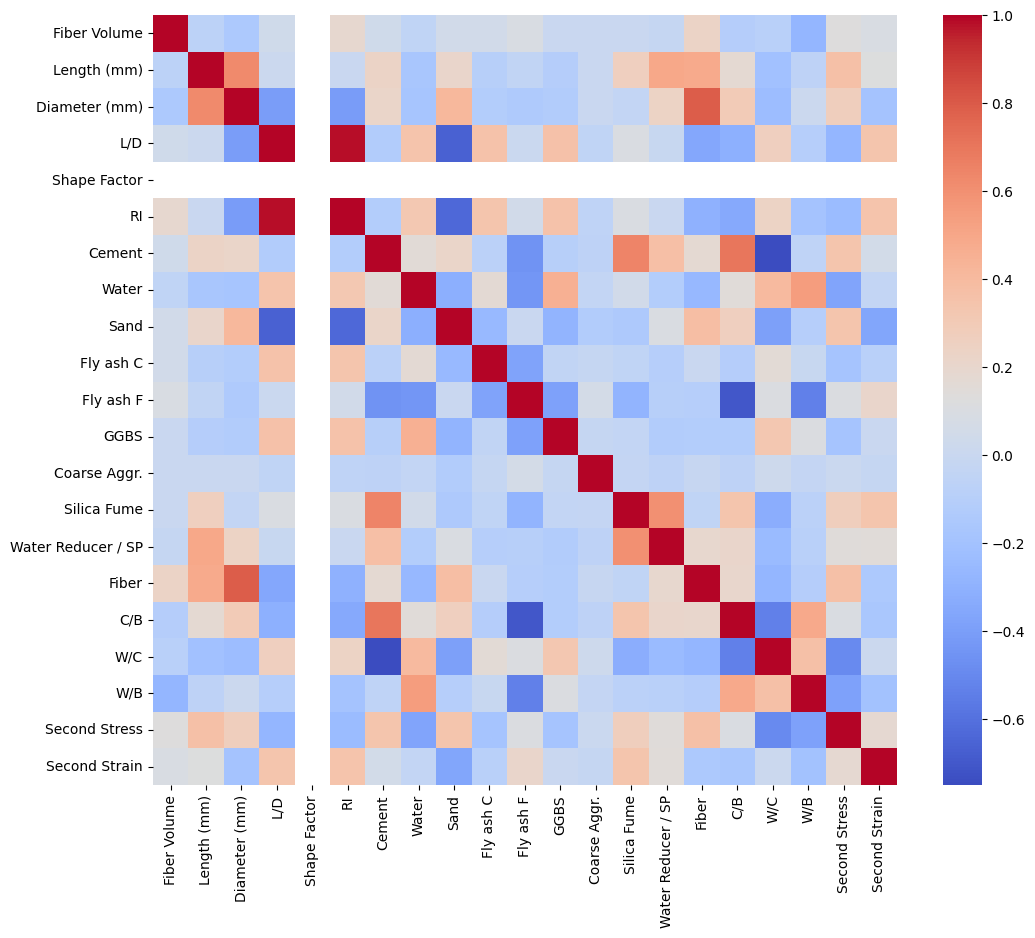

In [13]:
corr = df.corr(numeric_only=True)

plt.figure(figsize=(12,10))
sns.heatmap(corr, cmap="coolwarm")
plt.show()

In [19]:
px.box(df, x="Fiber Type", y="Second Stress",
       title="Fiber Type vs Strength").show()


In [21]:
px.scatter(
    df,
    x="Second Strain",
    y="Second Stress",
    color="Fiber Type",
    size="Fiber Volume",
    title="ECC Performance by Fiber"
).show()

In [20]:
df=df.drop(columns=["Mixture","Specimen"])

In [22]:
df = pd.get_dummies(df, columns=["Fiber Type"])

In [24]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 44 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Fiber Volume                  506 non-null    float64
 1   Length (mm)                   506 non-null    float64
 2   Diameter (mm)                 506 non-null    float64
 3   L/D                           505 non-null    float64
 4   Shape Factor                  506 non-null    float64
 5   RI                            506 non-null    float64
 6   Cement                        506 non-null    float64
 7   Water                         506 non-null    float64
 8   Sand                          506 non-null    float64
 9   Fly ash C                     506 non-null    float64
 10  Fly ash F                     506 non-null    float64
 11  GGBS                          506 non-null    float64
 12  Coarse Aggr.                  506 non-null    float64
 13  Silica Fume     

In [25]:
df = df.dropna()

In [28]:
from sklearn.preprocessing import StandardScaler

X = df.drop(columns=["Second Stress", "Second Strain"])
y = df[["Second Stress", "Second Strain"]]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [29]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y,
    test_size=0.2,
    random_state=42
)

In [49]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.multioutput import MultiOutputRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import r2_score

models = {
    "Linear": LinearRegression(),
    "Ridge": Ridge(),
    "Lasso": Lasso(),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(random_state=42),
    "Gradient Boosting": MultiOutputRegressor(GradientBoostingRegressor())
}

for name, model in models.items():
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    score = r2_score(y_test, pred)
    print(f"{name}: R2 = {score:.3f}")

Linear: R2 = 0.645
Ridge: R2 = 0.682
Lasso: R2 = -0.012
Decision Tree: R2 = 0.841
Random Forest: R2 = 0.828
Gradient Boosting: R2 = 0.827
